# Cross-seed stability of filtered state estimates

This notebook evaluates the numerical stability of the latent-state estimates produced by the Normal SABR and memory-augmented Rough-SABR particle filters.

Five independent particle-filter runs are compared:

$$
s \in \{123,456,789,101112,131415\}.
$$

The analysis is restricted to timestamp indices available for every seed. Cross-seed dispersion therefore measures sensitivity to Monte Carlo and particle-filter randomness on a paired basis. It is a **numerical stability diagnostic**, not a measure of predictive accuracy or market fit.

## Method

For state variable \(X_t\), let \(\widehat X_t^{(s)}\) denote the filtered posterior mean obtained with seed \(s\). At each timestamp, stability is summarized by

$$
\operatorname{SD}_s\!\left(\widehat X_t^{(s)}\right),
$$

together with the cross-seed mean, median, minimum, maximum, and range.

The sample is also divided into three descriptive intervals:

- initial: timestamps \(0\)–\(50\);
- intermediate: timestamps \(51\)–\(220\);
- later: timestamps \(221\)–\(399\).

These intervals are descriptive only; they are not estimated structural breaks. Raw dispersion values should be compared **within the same state variable**, because the states have different units and scales.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# Repository-relative paths. Run this notebook from the notebooks/ directory.
OUTPUTS_DIR = Path("../outputs")
ANALYSIS_DIR = OUTPUTS_DIR / "comparisons" / "state_path_analysis"
FIGURE_DIR = ANALYSIS_DIR / "figures"
TABLE_DIR = ANALYSIS_DIR / "tables"

SEEDS = [123, 456, 789, 101112, 131415]
MAX_TIMESTAMPS = 400

NORMAL_RUNS = {
    seed: OUTPUTS_DIR / f"normal_sabr_400ts_no_A_RW_seed{seed}"
    for seed in SEEDS
}
ROUGH_RUNS = {
    seed: OUTPUTS_DIR / f"rough_sabr_400ts_logU0_seed{seed}"
    for seed in SEEDS
}

# Used only to derive the ATM volatility proxy when it is not already saved.
BETA = 0.7
FORWARD_SHIFT = 0.0

SAVE_OUTPUTS = True

if SAVE_OUTPUTS:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    TABLE_DIR.mkdir(parents=True, exist_ok=True)


STATE_META = {
    "F": {"label": "Filtered forward", "ylabel": r"$F_t$"},
    "U": {"label": "Baseline volatility level", "ylabel": r"$U_t$"},
    "A": {"label": "Effective volatility factor", "ylabel": r"$A_t$"},
    "rho": {"label": "Correlation", "ylabel": r"$\rho_t$"},
    "nu": {"label": "Volatility of volatility", "ylabel": r"$\nu_t$"},
    "rough_driver": {"label": "Aggregated rough driver", "ylabel": "Rough driver"},
    "memory_norm": {"label": "Memory-state norm", "ylabel": "Memory norm"},
    "atm_logvol_proxy": {
        "label": "ATM log-volatility proxy",
        "ylabel": "ATM log-volatility proxy",
    },
}

SHARED_STATES = ["F", "A", "rho", "nu", "atm_logvol_proxy"]
ROUGH_ONLY_STATES = ["U", "rough_driver", "memory_norm"]

STATE_ALIASES = {
    "F": ["F", "F_mean", "filtered_F", "forward", "forward_mean"],
    "U": ["U", "U_mean", "filtered_U", "baseline_volatility", "vol_level"],
    "A": ["A", "A_mean", "effective_A", "effective_volatility", "effective_vol"],
    "rho": ["rho", "rho_mean", "filtered_rho"],
    "nu": ["nu", "nu_mean", "filtered_nu"],
    "rough_driver": [
        "rough_driver",
        "rough_driver_mean",
        "memory_driver",
        "aggregated_rough_driver",
    ],
    "memory_norm": [
        "memory_norm",
        "memory_state_norm",
        "rough_memory_norm",
        "R_norm",
    ],
    "atm_logvol_proxy": [
        "atm_logvol_proxy",
        "atm_log_vol_proxy",
        "atm_vol_proxy",
        "atm_proxy",
    ],
}

PERIOD_ORDER = [
    "Initial: 0–50",
    "Intermediate: 51–220",
    "Later: 221–399",
]

## 1. Load and standardize the state paths

The two filtering scripts do not necessarily save identical column sets. The loader below standardizes recognized aliases and derives only quantities that can be reconstructed without changing the model definition.

In particular, the Rough-SABR effective volatility factor \(A_t\) is taken from the saved filter output. It is not reconstructed from \(U_t\) and the rough driver because the repository implementation includes a rough-variance correction in that transformation.

In [2]:
def find_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """Return the first matching column, ignoring capitalization."""
    lookup = {column.lower(): column for column in df.columns}
    for candidate in candidates:
        if candidate.lower() in lookup:
            return lookup[candidate.lower()]
    return None


def find_memory_factor_columns(df: pd.DataFrame) -> list[str]:
    """Detect saved memory factors such as R1, R_1, or R2_mean."""
    pattern = re.compile(r"^[Rr]_?\d+(?:_mean)?$")
    return sorted(column for column in df.columns if pattern.match(column))


def assign_period(t_index: int) -> str:
    if t_index <= 50:
        return PERIOD_ORDER[0]
    if t_index <= 220:
        return PERIOD_ORDER[1]
    return PERIOD_ORDER[2]


def derive_atm_proxy(df: pd.DataFrame) -> pd.Series:
    shifted_forward = df["F"] + FORWARD_SHIFT
    proxy = pd.Series(np.nan, index=df.index, dtype=float)
    valid = shifted_forward > 0
    proxy.loc[valid] = (
        df.loc[valid, "A"]
        * shifted_forward.loc[valid] ** (BETA - 1.0)
    )
    return proxy


def load_state_path(path: Path, seed: int, model: str) -> pd.DataFrame:
    """Load one filtered_state_path.csv and standardize its state columns."""
    if not path.exists():
        raise FileNotFoundError(f"Filtered-state file not found: {path.resolve()}")

    raw = pd.read_csv(path)
    time_column = find_column(raw, ["t_index", "timestamp_index", "time_index"])
    if time_column is None:
        raise ValueError(f"No timestamp-index column found in {path}")

    result = pd.DataFrame({
        "t_index": pd.to_numeric(raw[time_column], errors="coerce")
    })

    for state, aliases in STATE_ALIASES.items():
        source = find_column(raw, aliases)
        if source is not None:
            result[state] = pd.to_numeric(raw[source], errors="coerce")

    # The memory norm is a descriptive quantity and can be reconstructed exactly
    # from saved memory-factor posterior means when it is absent.
    if model == "Rough-SABR" and "memory_norm" not in result:
        memory_columns = find_memory_factor_columns(raw)
        if memory_columns:
            memory = raw[memory_columns].apply(pd.to_numeric, errors="coerce")
            result["memory_norm"] = np.sqrt(np.square(memory).sum(axis=1))

    if (
        "atm_logvol_proxy" not in result
        and {"F", "A"}.issubset(result.columns)
    ):
        result["atm_logvol_proxy"] = derive_atm_proxy(result)

    required = {"F", "A", "rho", "nu"}
    missing = required.difference(result.columns)
    if missing:
        raise ValueError(
            f"{model} seed {seed} is missing required states {sorted(missing)}. "
            f"Available columns: {raw.columns.tolist()}"
        )

    result = (
        result.dropna(subset=["t_index"])
        .sort_values("t_index")
        .drop_duplicates("t_index", keep="last")
        .head(MAX_TIMESTAMPS)
        .reset_index(drop=True)
    )
    result["t_index"] = result["t_index"].astype(int)
    result["seed"] = seed
    result["model"] = model
    return result


def load_model_runs(run_folders: dict[int, Path], model: str) -> pd.DataFrame:
    frames = []
    for seed, folder in run_folders.items():
        frames.append(
            load_state_path(
                folder / "filtered_state_path.csv",
                seed=seed,
                model=model,
            )
        )
    return pd.concat(frames, ignore_index=True, sort=False)


def align_common_timestamps(states: pd.DataFrame) -> pd.DataFrame:
    """Retain timestamps present for every seed within each model."""
    counts = states.groupby(["model", "t_index"])["seed"].nunique()
    common_by_model = {
        model: set(group[group == len(SEEDS)].index.get_level_values("t_index"))
        for model, group in counts.groupby(level="model")
    }
    common = set.intersection(*common_by_model.values())
    if not common:
        raise ValueError("The two models have no timestamp shared by every seed.")

    return (
        states[states["t_index"].isin(common)]
        .sort_values(["model", "seed", "t_index"])
        .reset_index(drop=True)
    )

In [3]:
normal_states = load_model_runs(NORMAL_RUNS, "Normal SABR")
rough_states = load_model_runs(ROUGH_RUNS, "Rough-SABR")

states = align_common_timestamps(
    pd.concat([normal_states, rough_states], ignore_index=True, sort=False)
)

available_by_model = {
    model: [
        state
        for state in STATE_META
        if state in group.columns and group[state].notna().any()
    ]
    for model, group in states.groupby("model")
}

audit = (
    states.groupby(["model", "seed"])
    .agg(
        observations=("t_index", "size"),
        first_timestamp=("t_index", "min"),
        last_timestamp=("t_index", "max"),
    )
    .reset_index()
)

audit["available_states"] = audit["model"].map(
    lambda model: ", ".join(available_by_model[model])
)

display(audit)

if SAVE_OUTPUTS:
    states.to_csv(TABLE_DIR / "filtered_states_all_seeds.csv", index=False)
    audit.to_csv(TABLE_DIR / "state_path_data_audit.csv", index=False)

,model,seed,observations,first_timestamp,last_timestamp,available_states
0,Normal SABR,123,400,0,399,"F, A, rho, nu, atm_logvol_proxy"
1,Normal SABR,456,400,0,399,"F, A, rho, nu, atm_logvol_proxy"
2,Normal SABR,789,400,0,399,"F, A, rho, nu, atm_logvol_proxy"
3,Normal SABR,101112,400,0,399,"F, A, rho, nu, atm_logvol_proxy"
4,Normal SABR,131415,400,0,399,"F, A, rho, nu, atm_logvol_proxy"
5,Rough-SABR,123,400,0,399,"F, U, A, rho, nu, rough_driver, memory_norm, a..."
6,Rough-SABR,456,400,0,399,"F, U, A, rho, nu, rough_driver, memory_norm, a..."
7,Rough-SABR,789,400,0,399,"F, U, A, rho, nu, rough_driver, memory_norm, a..."
8,Rough-SABR,101112,400,0,399,"F, U, A, rho, nu, rough_driver, memory_norm, a..."
9,Rough-SABR,131415,400,0,399,"F, U, A, rho, nu, rough_driver, memory_norm, a..."


## 2. Filtered state trajectories

Each figure places the Normal SABR and Rough-SABR trajectories side by side for an economically comparable state. The five lines within each panel correspond to the five random seeds. Close overlap indicates that the posterior mean path is not materially driven by the seed.

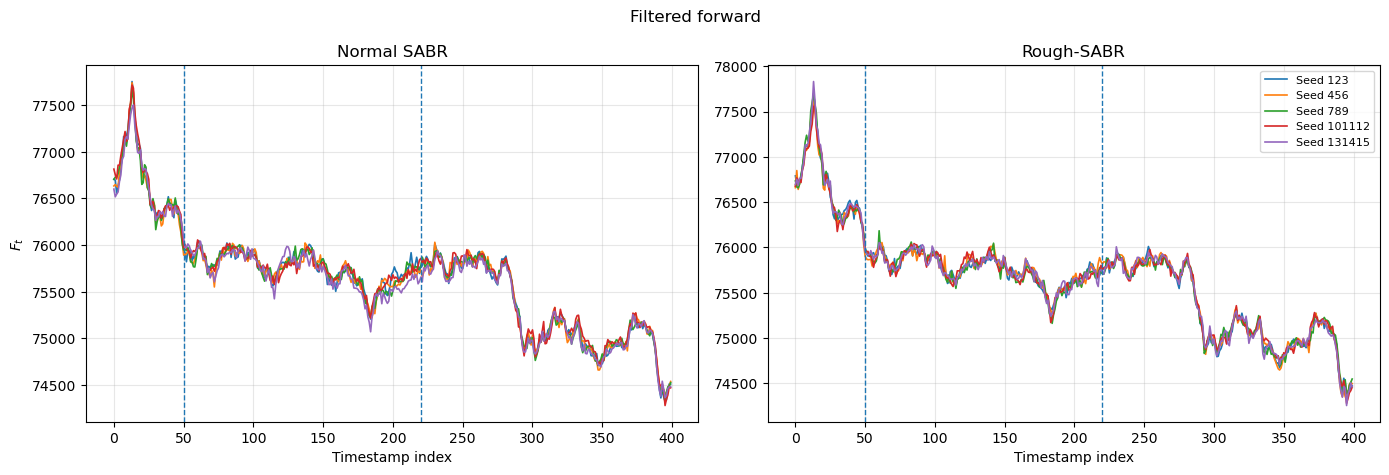

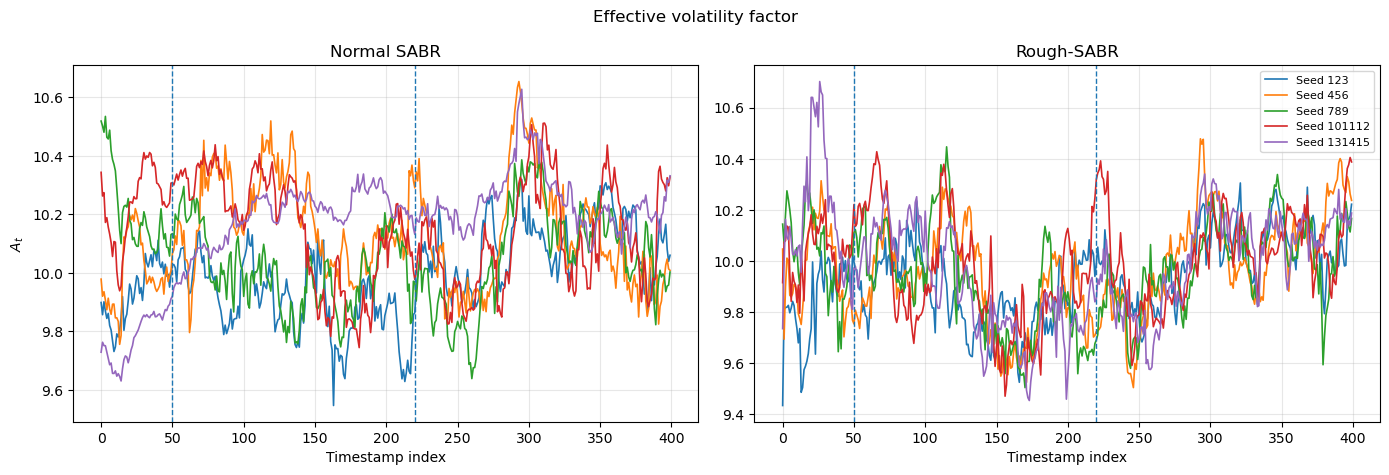

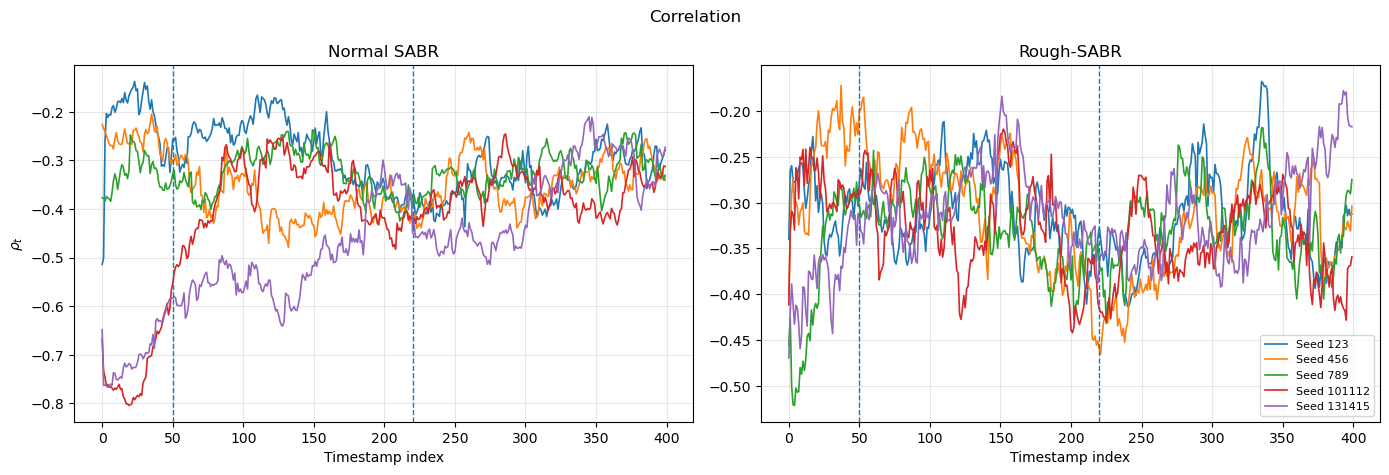

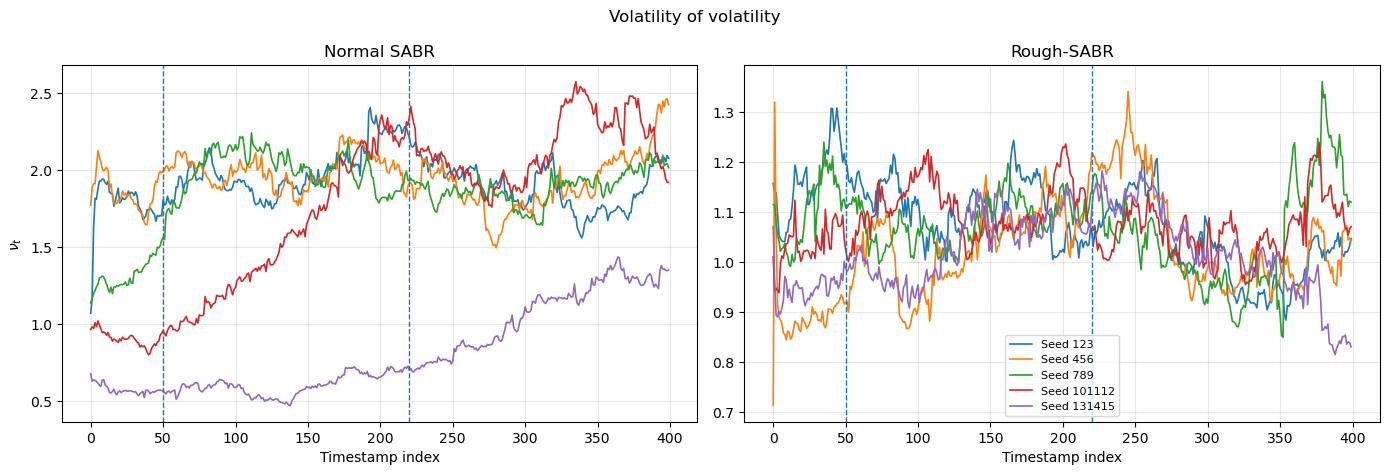

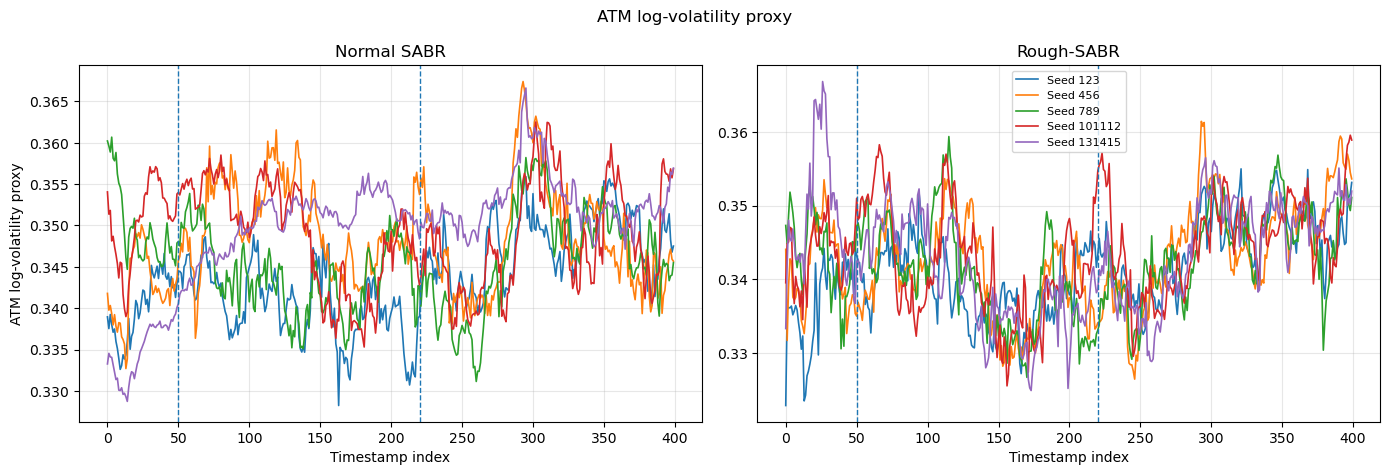

In [4]:
shared_available = [
    state
    for state in SHARED_STATES
    if all(state in available_by_model[model] for model in available_by_model)
]

for state in shared_available:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True)
    settings = STATE_META[state]

    for ax, model in zip(axes, ["Normal SABR", "Rough-SABR"]):
        model_data = states[states["model"] == model]
        for seed, seed_data in model_data.groupby("seed"):
            ax.plot(
                seed_data["t_index"],
                seed_data[state],
                linewidth=1.2,
                label=f"Seed {seed}",
            )

        for boundary in (50, 220):
            ax.axvline(boundary, linestyle="--", linewidth=1)
        ax.set_title(model)
        ax.set_xlabel("Timestamp index")
        ax.grid(alpha=0.3)

    axes[0].set_ylabel(settings["ylabel"])
    axes[1].legend(loc="best", fontsize=8)
    fig.suptitle(settings["label"])
    fig.tight_layout()

    if SAVE_OUTPUTS:
        fig.savefig(
            FIGURE_DIR / f"{state}_paths_by_seed.png",
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()
    plt.close(fig)

### Rough-SABR-specific states

The baseline volatility level, aggregated rough driver, and memory-state norm have no direct Normal SABR counterpart. They are retained because they help diagnose whether the additional memory state itself is stable across seeds.

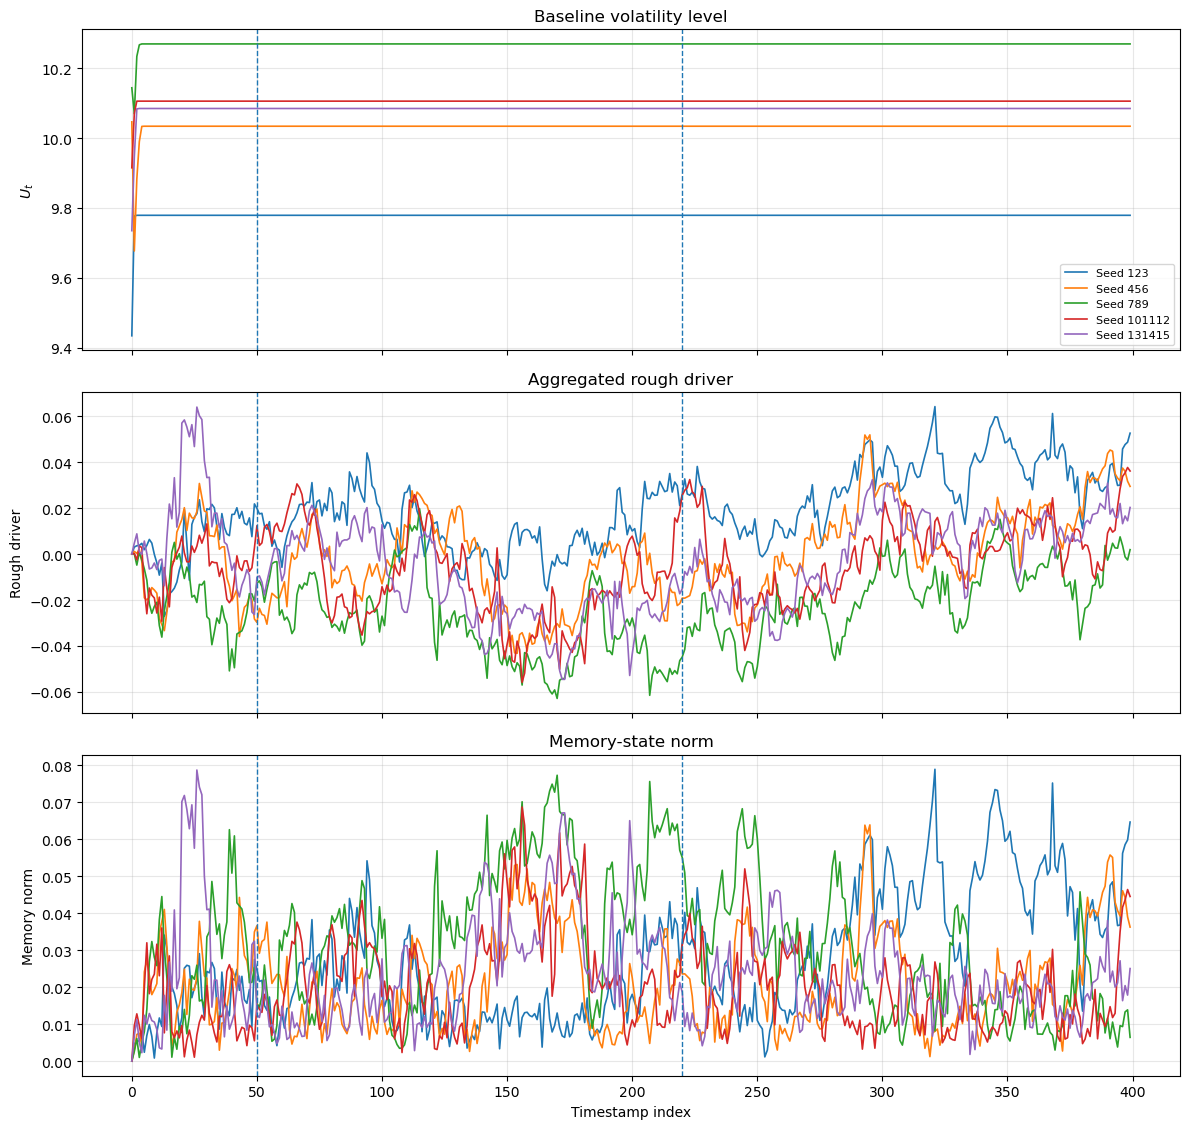

In [5]:
rough_specific_available = [
    state
    for state in ROUGH_ONLY_STATES
    if state in available_by_model["Rough-SABR"]
]

if rough_specific_available:
    fig, axes = plt.subplots(
        len(rough_specific_available),
        1,
        figsize=(12, 3.8 * len(rough_specific_available)),
        sharex=True,
    )
    axes = np.atleast_1d(axes)
    rough_data = states[states["model"] == "Rough-SABR"]

    for ax, state in zip(axes, rough_specific_available):
        for seed, seed_data in rough_data.groupby("seed"):
            ax.plot(
                seed_data["t_index"],
                seed_data[state],
                linewidth=1.2,
                label=f"Seed {seed}",
            )

        for boundary in (50, 220):
            ax.axvline(boundary, linestyle="--", linewidth=1)
        ax.set_title(STATE_META[state]["label"])
        ax.set_ylabel(STATE_META[state]["ylabel"])
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel("Timestamp index")
    axes[0].legend(loc="best", fontsize=8)
    fig.tight_layout()

    if SAVE_OUTPUTS:
        fig.savefig(
            FIGURE_DIR / "rough_specific_state_paths_by_seed.png",
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()
    plt.close(fig)

## 3. Cross-seed dispersion

The state paths are converted to long form and summarized at each timestamp. The central comparison uses the cross-seed standard deviation. A lower curve indicates greater agreement across independent particle-filter runs.

In [6]:
state_columns = [
    state
    for state in STATE_META
    if state in states.columns and states[state].notna().any()
]

state_long = states.melt(
    id_vars=["model", "seed", "t_index"],
    value_vars=state_columns,
    var_name="state",
    value_name="value",
).dropna(subset=["value"])

dispersion = (
    state_long.groupby(["model", "state", "t_index"])
    .agg(
        across_seed_mean=("value", "mean"),
        across_seed_median=("value", "median"),
        across_seed_std=("value", "std"),
        across_seed_min=("value", "min"),
        across_seed_max=("value", "max"),
        number_of_seeds=("seed", "nunique"),
    )
    .reset_index()
)

dispersion["across_seed_range"] = (
    dispersion["across_seed_max"] - dispersion["across_seed_min"]
)
dispersion["period"] = pd.Categorical(
    dispersion["t_index"].map(assign_period),
    categories=PERIOD_ORDER,
    ordered=True,
)

if SAVE_OUTPUTS:
    dispersion.to_csv(TABLE_DIR / "state_dispersion_by_timestamp.csv", index=False)

display(dispersion.head())

,model,state,t_index,across_seed_mean,across_seed_median,across_seed_std,across_seed_min,across_seed_max,number_of_seeds,across_seed_range,period
0,Normal SABR,A,0,10.093838,9.978640,0.327239,9.728584,10.519302,5,0.790718,Initial: 0–50
1,Normal SABR,A,1,10.060998,9.920074,0.310690,9.762666,10.502307,5,0.739641,Initial: 0–50
2,Normal SABR,A,2,10.068712,9.935702,0.299568,9.751176,10.481103,5,0.729927,Initial: 0–50
3,Normal SABR,A,3,10.046807,9.906517,0.313658,9.750642,10.535360,5,0.784718,Initial: 0–50
4,Normal SABR,A,4,10.020011,9.873759,0.301089,9.729094,10.464003,5,0.734909,Initial: 0–50


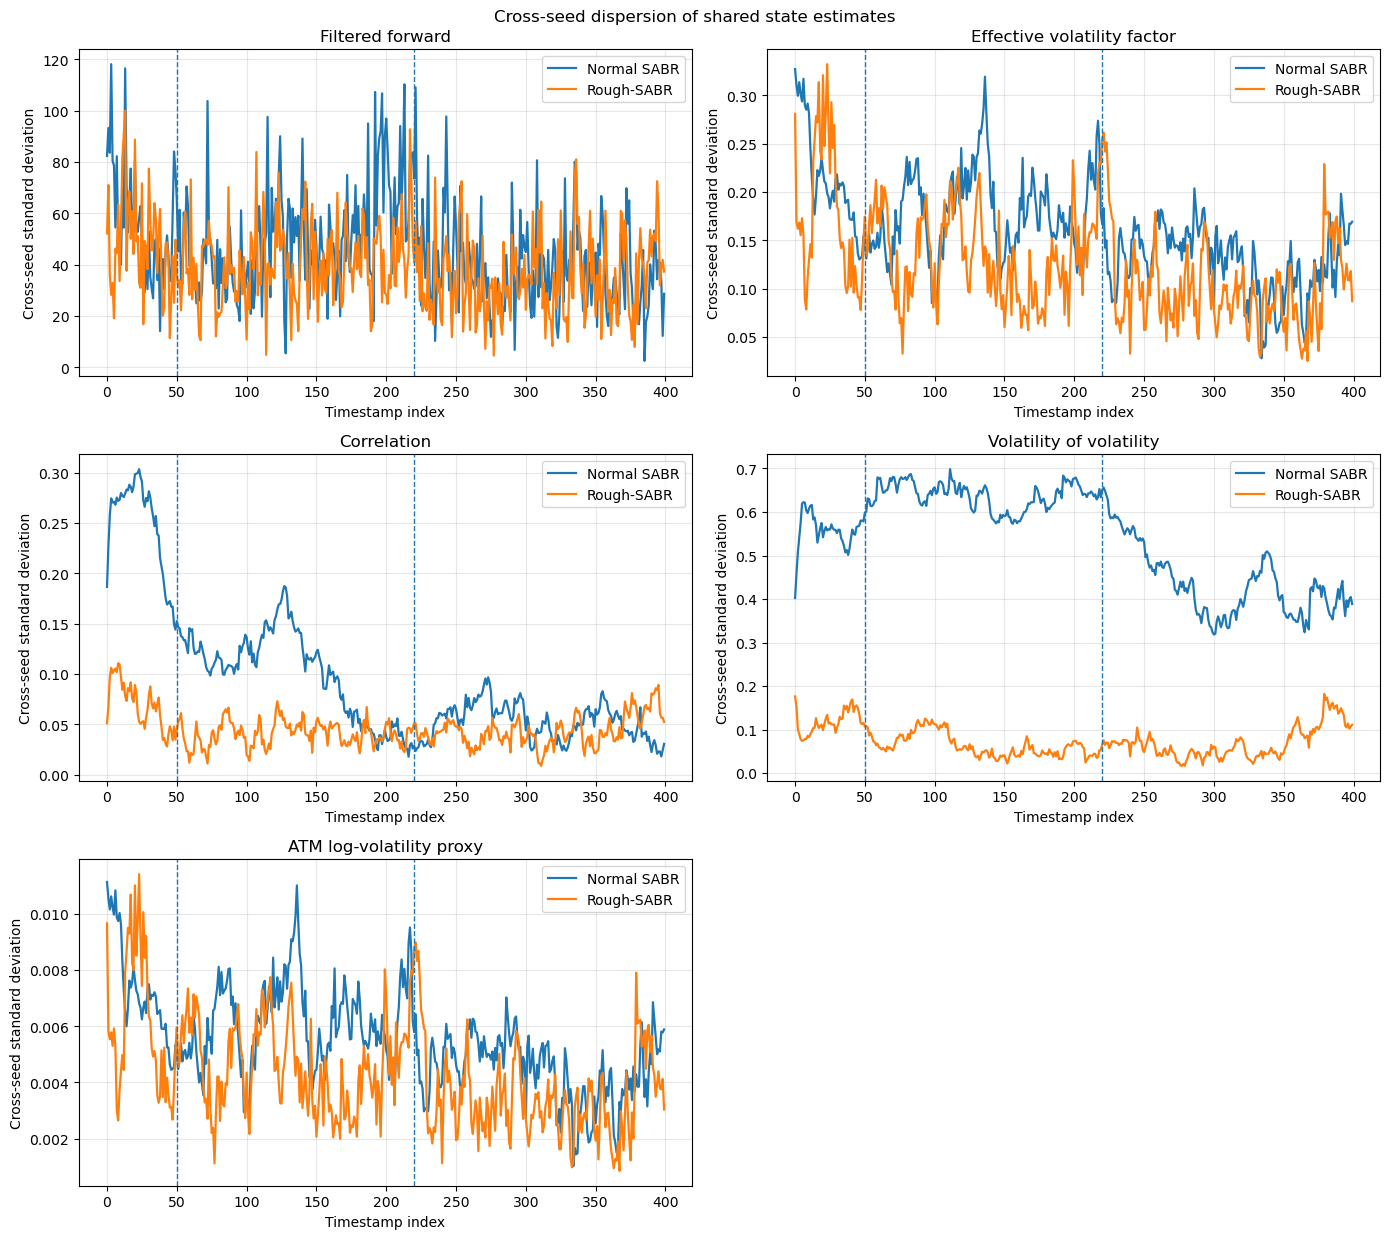

In [7]:
n_states = len(shared_available)
n_cols = 2
n_rows = int(np.ceil(n_states / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4.2 * n_rows),
    squeeze=False,
)
axes_flat = axes.ravel()

for ax, state in zip(axes_flat, shared_available):
    plot_data = dispersion[dispersion["state"] == state]
    for model, group in plot_data.groupby("model"):
        ax.plot(
            group["t_index"],
            group["across_seed_std"],
            linewidth=1.6,
            label=model,
        )

    for boundary in (50, 220):
        ax.axvline(boundary, linestyle="--", linewidth=1)
    ax.set_title(STATE_META[state]["label"])
    ax.set_xlabel("Timestamp index")
    ax.set_ylabel("Cross-seed standard deviation")
    ax.grid(alpha=0.3)
    ax.legend()

for ax in axes_flat[n_states:]:
    ax.set_visible(False)

fig.suptitle("Cross-seed dispersion of shared state estimates")
fig.tight_layout()

if SAVE_OUTPUTS:
    fig.savefig(
        FIGURE_DIR / "shared_state_cross_seed_dispersion.png",
        dpi=300,
        bbox_inches="tight",
    )

plt.show()
plt.close(fig)

## 4. Period-level stability summary

Averaging the timestamp-level standard deviations within each descriptive period gives a compact stability table. The table reports raw state-specific dispersion and the difference

$$
\overline{\operatorname{SD}}_{	ext{Rough}}
-
\overline{\operatorname{SD}}_{	ext{Normal}}.
$$

Positive differences indicate greater cross-seed dispersion for Rough-SABR; negative differences indicate greater dispersion for Normal SABR.

In [8]:
period_summary = (
    dispersion[dispersion["state"].isin(shared_available)]
    .groupby(["state", "period", "model"], observed=True)
    .agg(
        mean_cross_seed_std=("across_seed_std", "mean"),
        median_cross_seed_std=("across_seed_std", "median"),
        maximum_cross_seed_std=("across_seed_std", "max"),
    )
    .reset_index()
)

mean_dispersion_comparison = (
    period_summary.pivot(
        index=["state", "period"],
        columns="model",
        values="mean_cross_seed_std",
    )
    .reset_index()
)

mean_dispersion_comparison["Rough minus Normal"] = (
    mean_dispersion_comparison["Rough-SABR"]
    - mean_dispersion_comparison["Normal SABR"]
)

mean_dispersion_comparison = mean_dispersion_comparison.sort_values(
    ["state", "period"]
).reset_index(drop=True)

display(mean_dispersion_comparison)

if SAVE_OUTPUTS:
    period_summary.to_csv(
        TABLE_DIR / "period_level_state_dispersion.csv",
        index=False,
    )
    mean_dispersion_comparison.to_csv(
        TABLE_DIR / "period_level_model_comparison.csv",
        index=False,
    )

model,state,period,Normal SABR,Rough-SABR,Rough minus Normal
0,A,Initial: 0–50,0.213747,0.179201,-0.034546
1,A,Intermediate: 51–220,0.178530,0.134039,-0.044491
2,A,Later: 221–399,0.127517,0.099603,-0.027914
3,F,Initial: 0–50,56.153381,48.414637,-7.738744
4,F,Intermediate: 51–220,50.762764,40.329350,-10.433414
5,F,Later: 221–399,38.123161,34.794342,-3.328819
6,atm_logvol_proxy,Initial: 0–50,0.007302,0.006130,-0.001171
7,atm_logvol_proxy,Intermediate: 51–220,0.006159,0.004610,-0.001548
8,atm_logvol_proxy,Later: 221–399,0.004409,0.003441,-0.000968
9,nu,Initial: 0–50,0.558340,0.118123,-0.440217
